## 1. Introducción
Este notebook implementa un sistema de detección de manchas solares utilizando el modelo de detección de objetos YOLOv8.
El objetivo es identificar y localizar manchas solares en imágenes solares.
Utilizaremos un modelo YOLOv8 pre-entrenado y lo ajustaremos (fine-tuning) con un dataset de imágenes de manchas solares.
**Nota:** Este notebook utiliza un dataset externo para el entrenamiento debido a problemas con la generación automática de anotaciones a partir de los datos SRS.


### Importar Biblioteca

In [1]:
import os
import glob
import time
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw
#from PIL import Image
import yaml

%matplotlib inline


### Definición de Rutas y Configuraciones

In [2]:
dataset_config = r"C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2.yaml"  # Ruta al archivo data.yaml
project_name = "dataset2_model"  # Nombre del proyecto
run_name = "dataset2_simple_nano"  # Nombre de la ejecución del entrenamiento
model_dir = os.path.join(
    project_name, run_name, "weights"
)  # Directorio para guardar el modelo entrenado

## Cargar Modelo Pre-entrenado

In [3]:
# Comprobar si existe un modelo anterior para reanudar
best_model_path = os.path.join(model_dir, "best.pt")
last_model_path = os.path.join(model_dir, "last.pt")

# Cargar el modelo (previo o nuevo)
if os.path.exists(best_model_path):
    print(f"Reanudando entrenamiento desde el mejor modelo guardado: {best_model_path}")
    model = YOLO(best_model_path)
elif os.path.exists(last_model_path):
    print(
        f"Reanudando entrenamiento desde el último modelo guardado: {last_model_path}"
    )
    model = YOLO(last_model_path)
else:
    print("No se encontró modelo previo. Iniciando nuevo entrenamiento con YOLOv8n")
    model = YOLO("yolov8n.pt")

No se encontró modelo previo. Iniciando nuevo entrenamiento con YOLOv8n


## Entrenar el Modelo

In [4]:
trained_model_path = "OGAUC_model/OGAUC_simple_nano/weights/best.pt"
model = YOLO(trained_model_path)

results = model.train(
    data=dataset_config,
    epochs=15,  # Número total de épocas deseadas
    imgsz=640,
    batch=16,
    patience=10,
    save=True,
    save_period=5,  # Guardar cada 5 épocas
    project=project_name,
    name=run_name,
    exist_ok=True,  # Permitir sobreescribir resultados anteriores
    # Data augmentation desactivada para evitar redundancia:
    fliplr=0.0,      # Flip horizontal aleatorio desactivado
    scale=0.0,       # Escalado aleatorio desactivado
    hsv_h=0.0,       # Color jittering (hue) desactivado
    hsv_s=0.0,       # Color jittering (saturation) desactivado
    hsv_v=0.0,       # Color jittering (brightness) desactivado
    mosaic=0.0,      # Mosaic ya estaba desactivado
    crop_fraction=0.0, # Recorte aleatorio desactivado
)

New https://pypi.org/project/ultralytics/8.3.161 available  Update with 'pip install -U ultralytics'
WARNING 'crop_fraction' is deprecated and will be removed in in the future.
Ultralytics 8.3.158  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 8700G w/ Radeon 780M Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=3

train: Scanning C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2\train\labels.cache... 4046 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4046/4046 [00:00<?, ?it/s]

val: Fast image access  (ping: 0.00.0 ms, read: 120.842.8 MB/s, size: 11.4 KB)



c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2\valid\labels.cache... 578 images, 0 backgrounds, 0 corrupt: 100%|██████████| 578/578 [00:00<?, ?it/s]
c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Plotting labels to dataset2_model\dataset2_simple_nano\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to dataset2_model\dataset2_simple_nano
Starting training for 15 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      15/15         0G      1.143     0.5534     0.8536         48        640: 100%|██████████| 253/253 [06:47<00:00,  1.61s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:23<00:00,  1.24s/it]

                   all        578       2115      0.837      0.884      0.901      0.544



15 epochs completed in 1.718 hours.
Optimizer stripped from dataset2_model\dataset2_simple_nano\weights\last.pt, 6.2MB
Optimizer stripped from dataset2_model\dataset2_simple_nano\weights\best.pt, 6.2MB

Validating dataset2_model\dataset2_simple_nano\weights\best.pt...
Ultralytics 8.3.158  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 8700G w/ Radeon 780M Graphics)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:18<00:00,  1.01it/s]


                   all        578       2115      0.845      0.875      0.909      0.547
Speed: 0.8ms preprocess, 28.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to dataset2_model\dataset2_simple_nano


### Métricas de Evaluación

Métricas de Evaluación (Mejor Época):
Época: 1
Tiempo de entrenamiento: 428.77 segundos
Precisión: 0.8698
Recall: 0.8497
mAP50: 0.9156
mAP50-95: 0.5169

Matriz de Confusión:


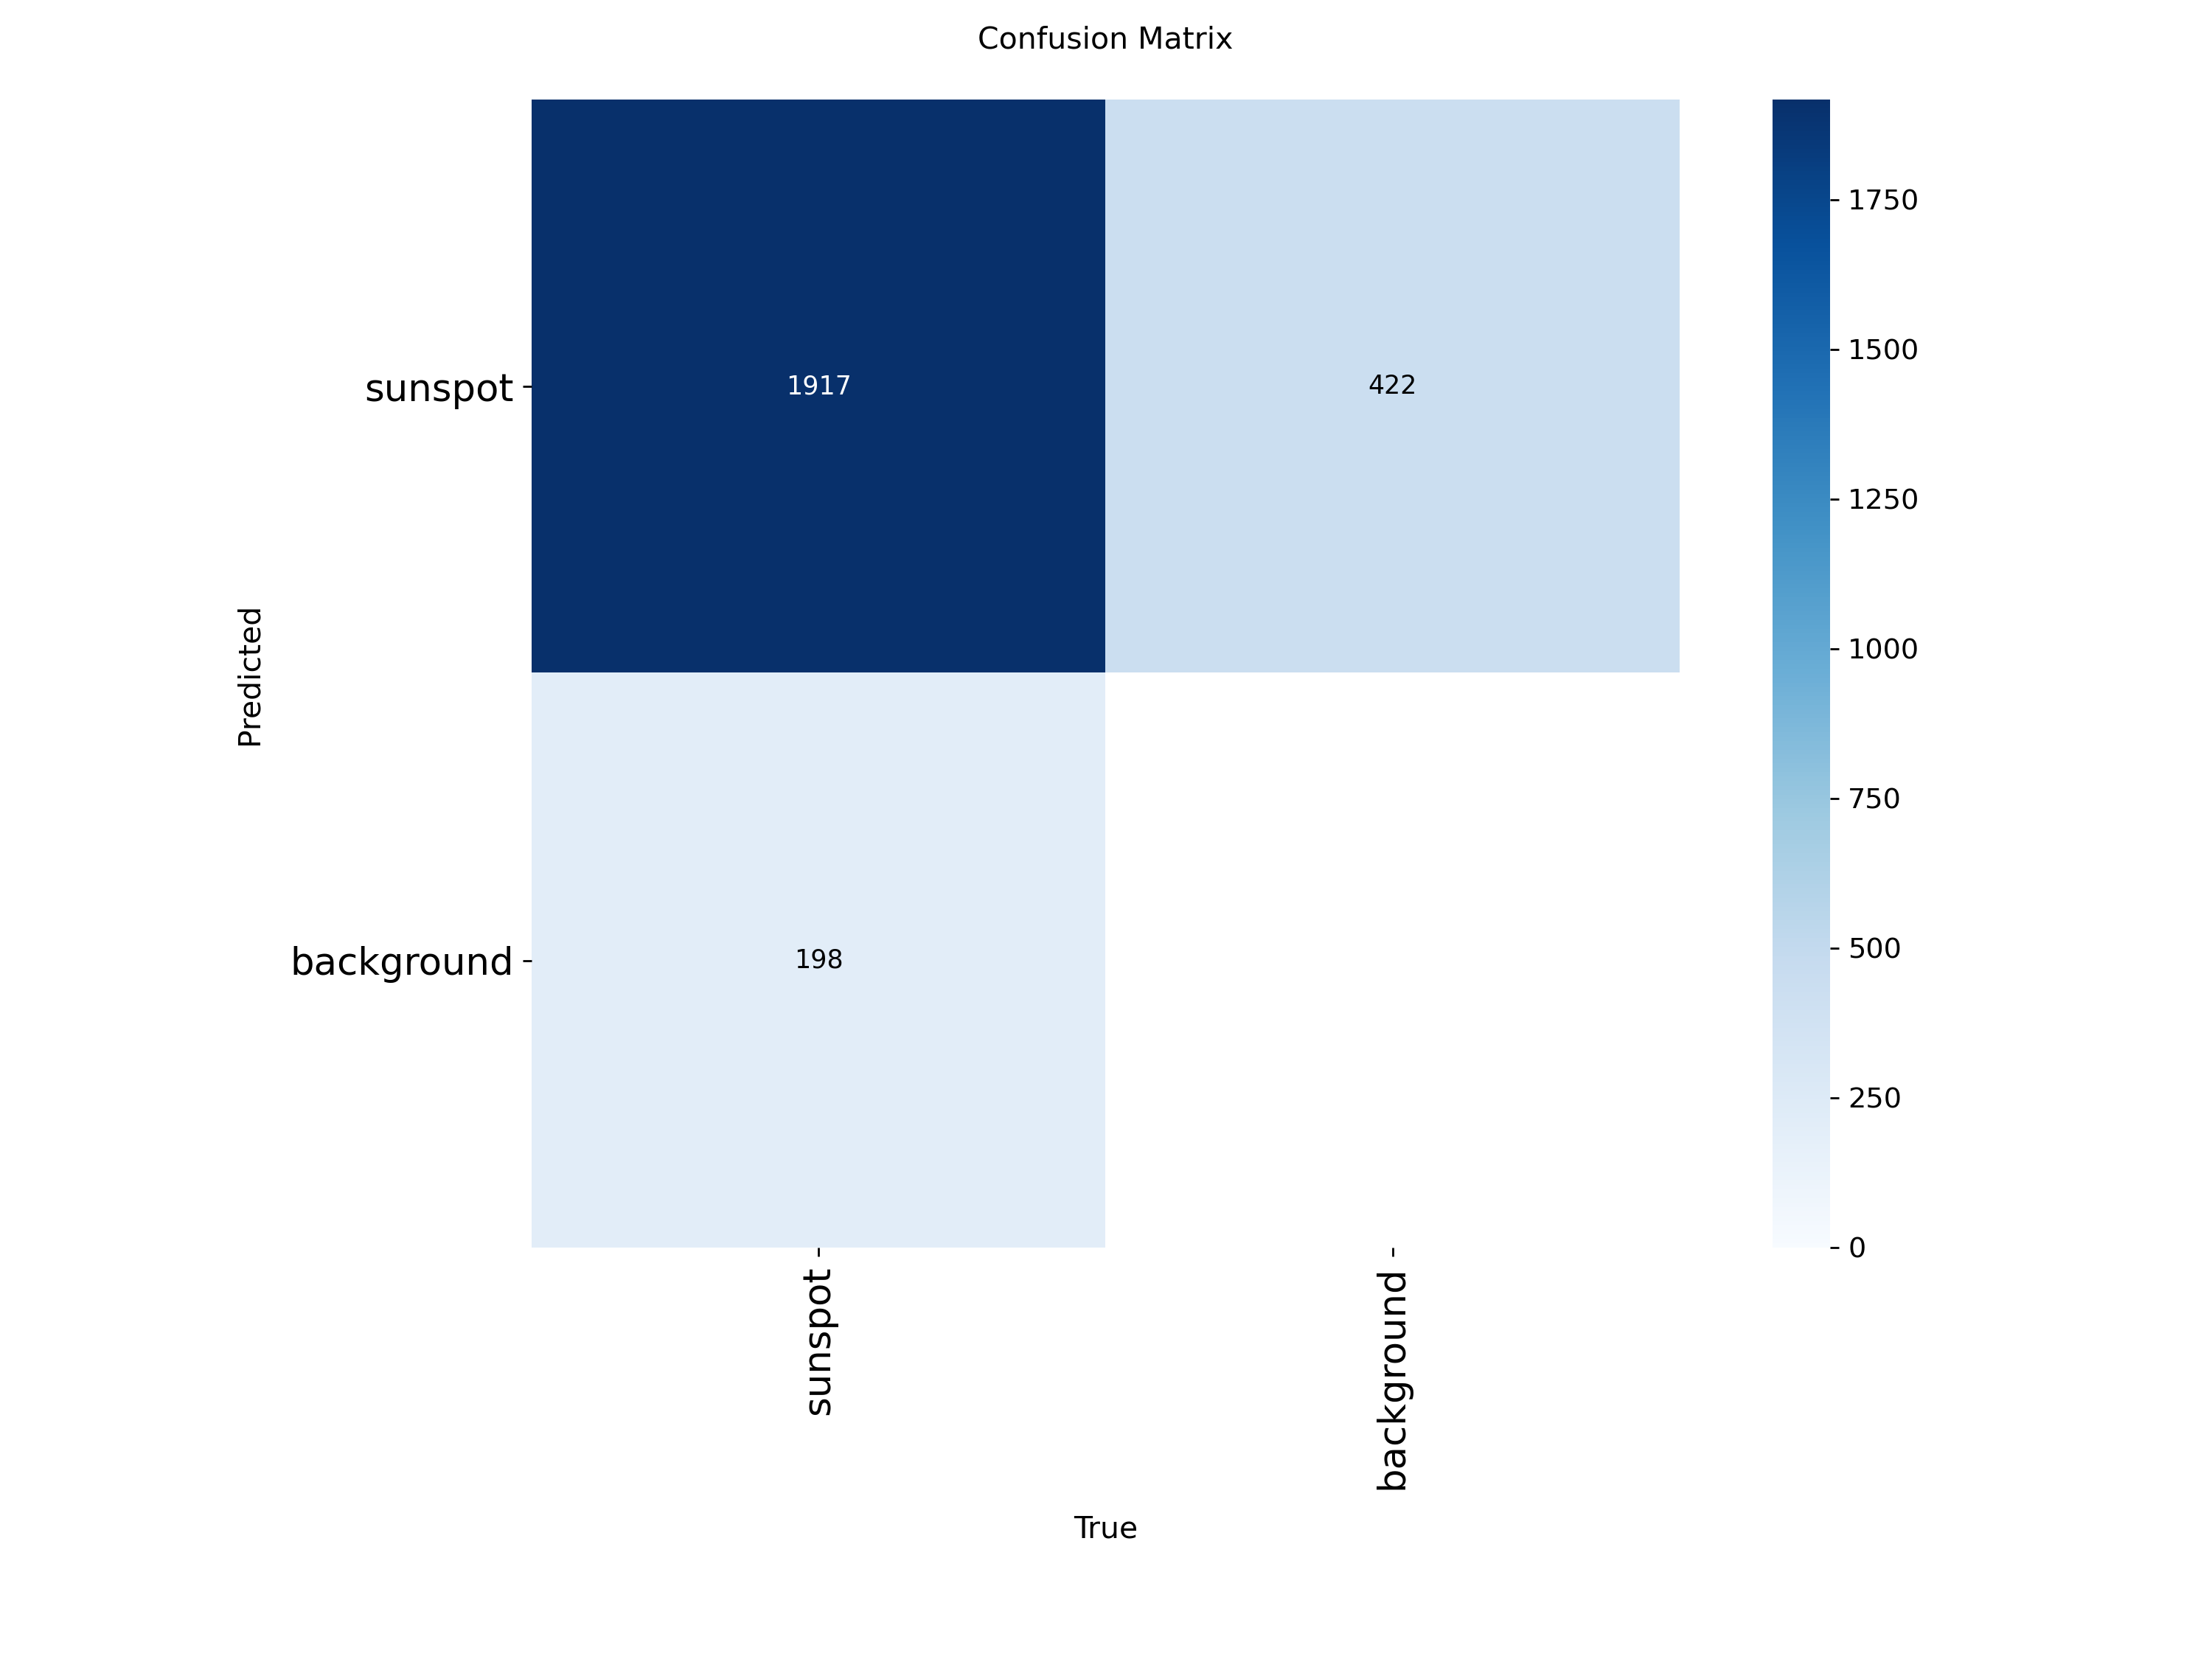


Curva Precisión-Recall:


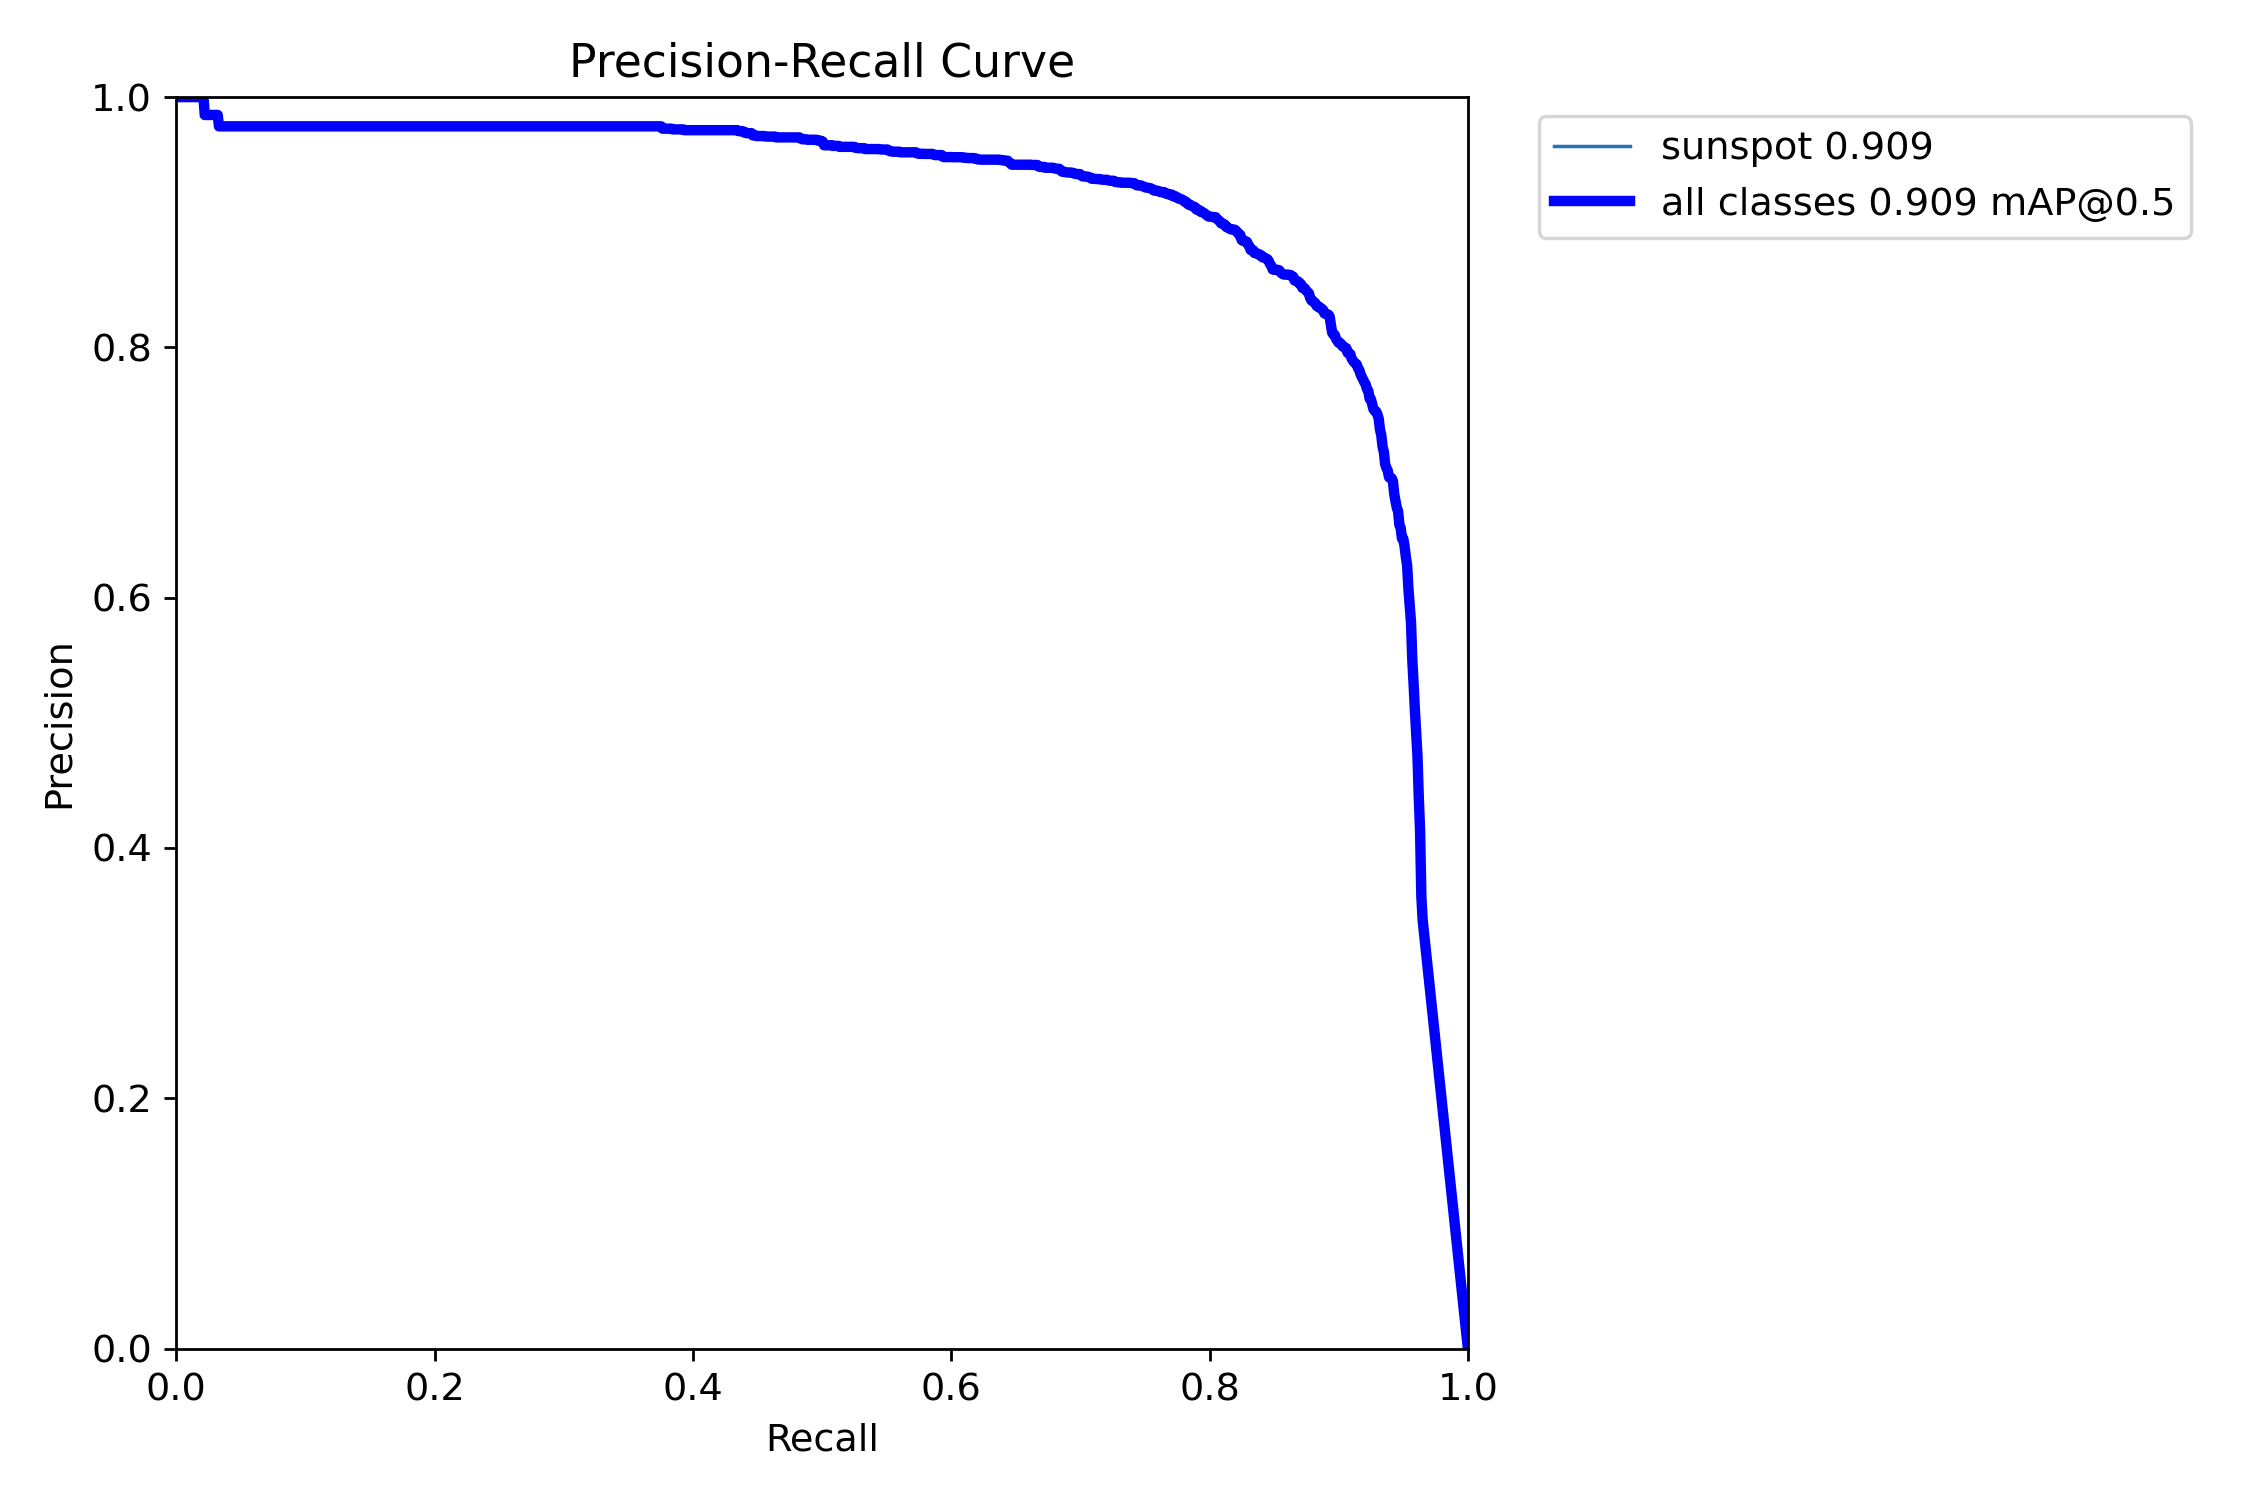

In [5]:
# Cargar las métricas de evaluación desde el archivo `results.csv`.
results_csv_path = os.path.join(project_name, run_name, "results.csv")

try:
    results_df = pd.read_csv(results_csv_path)
    # Buscar la fila con el mejor mAP50
    best_row = results_df.loc[results_df['metrics/mAP50(B)'].idxmax()]

    print("Métricas de Evaluación (Mejor Época):")
    print(f"Época: {int(best_row['epoch'])}")
    print(f"Tiempo de entrenamiento: {best_row['time']:.2f} segundos")
    print(f"Precisión: {best_row['metrics/precision(B)']:.4f}")
    print(f"Recall: {best_row['metrics/recall(B)']:.4f}")
    print(f"mAP50: {best_row['metrics/mAP50(B)']:.4f}")
    print(f"mAP50-95: {best_row['metrics/mAP50-95(B)']:.4f}")

except FileNotFoundError:
    print(f"Error: No se pudo encontrar el archivo {results_csv_path}")

# ### 5.2. Mostrar Visualizaciones de Evaluación
# Mostrar las visualizaciones de evaluación generadas, como la matriz de confusión y la curva de precisión-recall.
confusion_matrix_path = os.path.join(project_name, run_name, "confusion_matrix.png")
pr_curve_path = os.path.join(project_name, run_name, "PR_curve.png")

print("\nMatriz de Confusión:")
try:
    display(Image(filename=confusion_matrix_path))
except FileNotFoundError:
    print(f"Error: No se pudo encontrar la imagen {confusion_matrix_path}")

print("\nCurva Precisión-Recall:")
try:
    display(Image(filename=pr_curve_path))
except FileNotFoundError:
    print(f"Error: No se pudo encontrar la imagen {pr_curve_path}")

## Visualizar Predicciones en Imágenes de Prueba

In [6]:
# Obtener una lista de imágenes de prueba
test_images = glob.glob("dataset/OGAUC/valid/images/*.jpg")
# Seleccionar una imagen aleatoria
random_img_path = random.choice(test_images)
print(f"Imagen seleccionada: {random_img_path}")

Imagen seleccionada: dataset/OGAUC/valid/images\15122903CN_jpg.rf.4a83b7f33798546837868e2d8cac5521.jpg


In [7]:
# Cargar la imagen
img = cv2.imread(random_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Obtener la ruta al archivo de etiquetas correspondiente
label_path = random_img_path.replace("images", "labels").replace(".jpg", ".txt")

# Cargar etiquetas (ground truth)
labels = []

with open(label_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])
        # Convertir coordenadas normalizadas a píxeles
        img_height, img_width = img.shape[:2]
        x1 = int((x_center - width / 2) * img_width)
        y1 = int((y_center - height / 2) * img_height)
        x2 = int((x_center + width / 2) * img_width)
        y2 = int((y_center + height / 2) * img_height)
        labels.append((class_id, x1, y1, x2, y2))

labels

[(0, 285, 265, 307, 280), (0, 272, 273, 278, 280), (0, 253, 275, 268, 290)]

In [13]:
# Crear una copia para dibujar las etiquetas ground truth
img_gt = img.copy()
for idx, label in enumerate(labels):
    class_id, x1, y1, x2, y2 = label
    cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text_y = max(y1 - 10, 10)
    cv2.putText(
        img_gt,
        f"{idx}",
        (x1, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

# Realizar predicción con el modelo entrenado (sin filtrar por confianza)
pred_results = model.predict(random_img_path)

# Dibujar las predicciones con su confianza
img_pred = img.copy()
for idx, box in enumerate(pred_results[0].boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    conf = float(box.conf[0])
    #class_id = int(box.cls[0])
    cv2.rectangle(img_pred, (x1, y1), (x2, y2), (255, 0, 0), 2)
    # Asegura que el texto esté dentro de la imagen
    text_y = max(y1 - 10, 10)
    cv2.putText(
        img_pred,
        f"{idx}",
        (x1, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )


image 1/1 c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\OGAUC\valid\images\15122903CN_jpg.rf.4a83b7f33798546837868e2d8cac5521.jpg: 640x640 3 sunspots, 32.7ms
Speed: 1.8ms preprocess, 32.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


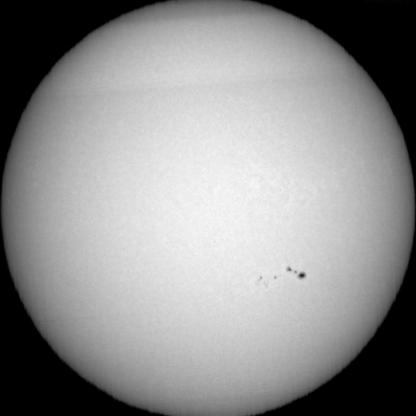

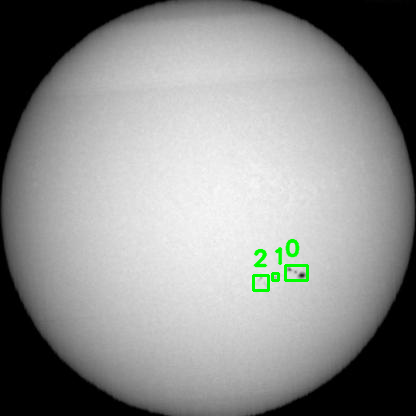

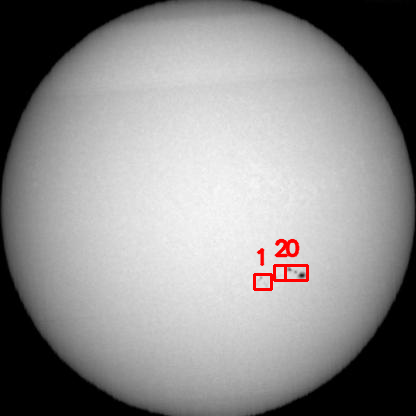

In [15]:
img_pil = PILImage.fromarray(img)
display(img_pil)
img_gt_pil = PILImage.fromarray(img_gt)
display(img_gt_pil)
img_pre_pil = PILImage.fromarray(img_pred)
display(img_pre_pil)

In [11]:
print("Labels:", len(labels))
print("Predictions:", len(pred_results[0].boxes))
for idx, box in enumerate(pred_results[0].boxes):
    conf = float(box.conf[0])
    print(f"Predicción {idx}: {box.xyxy[0].tolist()} con confianza {conf:.2f}")
    

Labels: 3
Predictions: 3
Predicción 0: [285.8426513671875, 265.40850830078125, 307.079833984375, 280.32330322265625] con confianza 0.67
Predicción 1: [254.70579528808594, 274.61480712890625, 271.7130126953125, 289.2254333496094] con confianza 0.52
Predicción 2: [274.3634338378906, 265.14892578125, 307.0027160644531, 280.8408203125] con confianza 0.38


## 7. Conclusiones
Este notebook presenta una implementación inicial de la detección de manchas solares utilizando YOLOv8.
Se realizó un entrenamiento de prueba con un dataset externo para evaluar la viabilidad del modelo y la configuración del entorno.
Los resultados obtenidos (Precisión: 0.4664, Recall: 0.5696, mAP50: 0.5346, mAP50-95: 0.2378) son modestos,
lo cual es esperable dado que el entrenamiento se limitó a una sola época.
El objetivo principal de esta ejecución fue verificar la correcta carga de datos, el funcionamiento del entrenamiento
y la generación de métricas básicas. Los hiperparámetros utilizados fueron los valores por defecto del modelo, sin ajustes específicos.
Los siguientes pasos a seguir incluyen:
- Aumentar significativamente el número de épocas de entrenamiento para permitir que el modelo converja.
- Evaluar el modelo en un conjunto de validación independiente para obtener una estimación más precisa de su capacidad de generalización.
- Investigar la posibilidad de utilizar los datos SRS para generar anotaciones y abordar la clasificación McIntosh en una etapa posterior.

In [7]:
new_dataset_config = r"C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2.yaml"  # Ruta al archivo data.yaml
trained_model_path = "OGAUC_model/OGAUC_simple_nano/weights/best.pt"
model = YOLO(trained_model_path)


In [10]:
metrics = model.val(data=new_dataset_config)
print("--- Métricas en Validation Set ---")
print(f"Precisión: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

# Obtener la matriz de confusión
conf_matrix = metrics.confusion_matrix.matrix

# Para una clase: TP es la diagonal, FN es la última columna, FP es la última fila
tp = conf_matrix[0, 0]
fn = conf_matrix[0, 1]
fp = conf_matrix[1, 0]

print("\nMatriz de Confusión (Validation Set):")
print(f"True Positives (TP): {int(tp)}")
print(f"False Negatives (FN): {int(fn)}")
print(f"False Positives (FP): {int(fp)}")

Ultralytics 8.3.158  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 8700G w/ Radeon 780M Graphics)
val: Fast image access  (ping: 0.00.0 ms, read: 208.547.3 MB/s, size: 11.6 KB)


val: Scanning C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2\valid\labels.cache... 578 images, 0 backgrounds, 0 corrupt: 100%|██████████| 578/578 [00:00<?, ?it/s]
c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 37/37 [00:18<00:00,  2.05it/s]


                   all        578       2115      0.898      0.875      0.938      0.567
Speed: 0.5ms preprocess, 26.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\runs\detect\val5
--- Métricas en Validation Set ---
Precisión: 0.8977
Recall: 0.8753
mAP50: 0.9381
mAP50-95: 0.5665

Matriz de Confusión (Validation Set):
True Positives (TP): 1958
False Negatives (FN): 392
False Positives (FP): 157


In [11]:
metrics_test = model.val(data=new_dataset_config, split='test')
print("\n--- Métricas en Test Set ---")
print(f"Precisión: {metrics_test.box.p[0]:.4f}")
print(f"Recall: {metrics_test.box.r[0]:.4f}")
print(f"mAP50: {metrics_test.box.map50:.4f}")
print(f"mAP50-95: {metrics_test.box.map:.4f}")

# Obtener la matriz de confusión del test set
conf_matrix_test = metrics_test.confusion_matrix.matrix

# Para una clase: TP es la diagonal, FN es la última columna, FP es la última fila
tp_test = conf_matrix_test[0, 0]
fn_test = conf_matrix_test[0, 1]
fp_test = conf_matrix_test[1, 0]

print("\nMatriz de Confusión (Test Set):")
print(f"True Positives (TP): {int(tp_test)}")
print(f"False Negatives (FN): {int(fn_test)}")
print(f"False Positives (FP): {int(fp_test)}")

Ultralytics 8.3.158  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 8700G w/ Radeon 780M Graphics)
val: Fast image access  (ping: 0.00.0 ms, read: 214.648.6 MB/s, size: 11.8 KB)


val: Scanning C:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\dataset\dataset2\test\labels.cache... 274 images, 0 backgrounds, 0 corrupt: 100%|██████████| 274/274 [00:00<?, ?it/s]
c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:08<00:00,  2.19it/s]


                   all        274       1026      0.906      0.884      0.944      0.574
Speed: 0.5ms preprocess, 25.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to c:\Users\DarkNacho\Documents\Doctorado\2025\MachineLearning\SunSpot\runs\detect\val6

--- Métricas en Test Set ---
Precisión: 0.9060
Recall: 0.8835
mAP50: 0.9441
mAP50-95: 0.5739

Matriz de Confusión (Test Set):
True Positives (TP): 956
False Negatives (FN): 161
False Positives (FP): 70
